In [1]:
import pandas as pd

In [1]:
import timm, torch
device = "cuda" if torch.cuda.is_available() else "cpu"
# pretrained encoders are hosted on HuggingFace under mwalmsley/
model = timm.create_model("hf_hub:mwalmsley/zoobot-encoder-convnext_nano", pretrained=True, num_classes=0).to(device).eval()
for p in model.parameters():
    p.requires_grad_(False)
cfg = timm.data.resolve_data_config({}, model=model)
print(cfg)   # input_size, mean, std, interpolation

{'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.95, 'crop_mode': 'center'}


In [3]:
acts = {}

#get "hook"
#hook: Runs after every layer, pyTorch tells you the layer, the input, output and 
def hook(_, __, out):
    acts["out"] = out

# Remove any old hooks first, then register exactly one 
#to clean up if you ran this multiple times in one session
for m in model.modules():
    m._forward_hooks.clear()
handle = model.stages[2].register_forward_hook(hook) #store output from 3rd layer everytime it runs

def dream(img, steps=100, lr=0.01, channel=None):
    x = img.detach().clone().requires_grad_(True) #cut off past history of image, make copy, and track how tensor dependent is the tensor
    for _ in range(steps):
        acts.clear()                       # never reuse a stale tensor
        model(x)
        a = acts["out"]                    # get output, courtesy of our hook function
        loss = a[:, channel].mean() if channel is not None else a.norm() #calculate loss -- ie what to focus on (one specific channel or look at big picutre)
        g, = torch.autograd.grad(loss, x)  # fresh graph each step, no .grad state
        with torch.no_grad():
            x += lr * g / (g.abs().mean() + 1e-8)
    return x.detach()

In [4]:
import torch
import numpy as np
from PIL import Image

#notmalization for the images 
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def load_img(path, max_side=512):
    im = Image.open(path).convert("RGB")          # drops alpha, fixes grayscale/palette PNGs ebcause deepDream works on color 
    im.thumbnail((max_side, max_side), Image.LANCZOS)  # keeps aspect ratio
    #convert into tensor flow format it expects
    x = torch.from_numpy(np.asarray(im)).float().div(255)  # (H,W,3) in [0,1]
    x = x.permute(2, 0, 1).unsqueeze(0).to(device)         # (1,3,H,W)
    return (x - mean) / std


def save_img(x, path):
    x = (x * std + mean).clamp(0, 1)               # undo normalisation
    #mirror image of last few steps
    x = x.squeeze(0).permute(1, 2, 0).cpu().numpy()
    Image.fromarray((x * 255).astype(np.uint8)).save(path)

In [ ]:

    #get number of channels

torch.Size([1, 320, 4, 4])


In [21]:
from pathlib import Path
from tqdm import tqdm

in_dir  = Path("./data_5/lens_png")
out_dir = Path("./deep_dream")
out_dir.mkdir(parents=True, exist_ok=True)

model = model.to(device).eval()
for p in model.parameters():
    p.requires_grad_(False)     # only the image needs gradients

paths = sorted(in_dir.glob("*.png"))
print(f"Found {len(paths)} images")

for path in tqdm(paths):
    out_path = out_dir / f"{path.stem}_dream.png"
    if out_path.exists():                 # lets you resume if interrupted
        continue
    try:
        img = load_img(str(path))
        out = dream(img, steps=100, lr=0.01, channel=None)
        save_img(out, str(out_path))
    except Exception as e:
        print(f"Skipped {path.name}: {e}")

Found 1000 images


100%|██████████| 1000/1000 [19:51:07<00:00, 71.47s/it]     


Examining Results:

In [15]:
import numpy as np, torch
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [20]:
img = load_img(str("./data_5/lens_png/lens_2001.png"))
with torch.no_grad():
    acts.clear()
    model(img)
    print(acts["out"].shape)

torch.Size([1, 320, 4, 4])


In [21]:
with torch.no_grad():
    acts.clear(); model(img)
    resp = acts["out"][0].mean(dim=(1, 2))   # one number per channel
    top = resp.topk(5).indices.tolist()      # the 5 strongest
print(top)

[58, 117, 63, 186, 253]


In [16]:
import matplotlib.pyplot as plt

def overlay(path, channel):
    img = load_img(path)
    with torch.no_grad():
        acts.clear(); model(img)
        amap = acts["out"][0, channel].cpu().numpy()   # (h, w)
    H, W = img.shape[2:]
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(to_np(img)); ax[0].set_title("image")
    ax[1].imshow(to_np(img))
    ax[1].imshow(amap, cmap="inferno", alpha=0.55,
                 extent=(0, W, H, 0), interpolation="bilinear")
    ax[1].set_title(f"channel {channel}")
    for a in ax: a.axis("off")
    plt.show()

In [17]:
def channel_gallery(path, channels, steps=100):
    img = load_img(path)
    fig, ax = plt.subplots(1, len(channels) + 1, figsize=(3 * (len(channels) + 1), 3))
    ax[0].imshow(to_np(img)); ax[0].set_title("original")
    for a, c in zip(ax[1:], channels):
        a.imshow(to_np(dream(img, steps=steps, lr=0.01, channel=c)))
        a.set_title(f"ch {c}")
    for a in ax: a.axis("off")
    plt.show()

In [30]:
def occlusion_map(img, channel, patch=32, stride=16):
    def score(x):
        with torch.no_grad():
            acts.clear(); model(x)
            return acts["out"][0, channel].mean().item()
    base, fill = score(img), img.mean().item()
    H, W = img.shape[2:]
    ys, xs = range(0, H - patch + 1, stride), range(0, W - patch + 1, stride)
    heat = np.zeros((len(ys), len(xs)))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            im2 = img.clone()
            im2[:, :, y:y+patch, x:x+patch] = fill
            heat[i, j] = base - score(im2)
    return heat

In [25]:
def to_np(x):
    x = (x * std + mean).clamp(0, 1)
    return x.squeeze(0).permute(1, 2, 0).cpu().numpy()

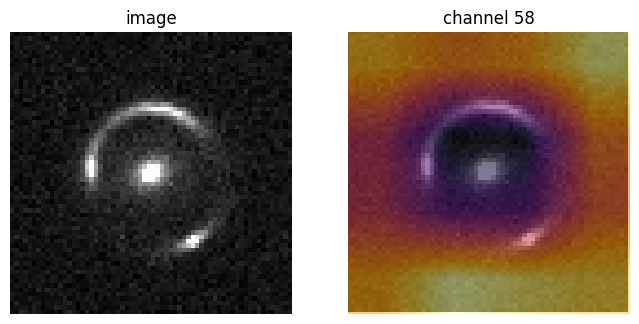

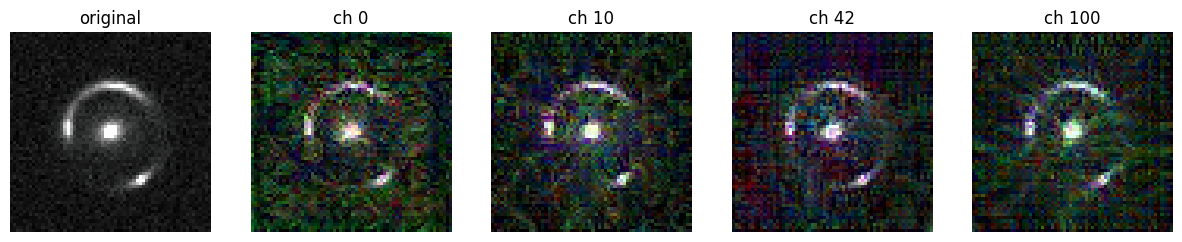

In [26]:
overlay("./data_5/lens_png/lens_2000.png", channel=58)
channel_gallery("./data_5/lens_png/lens_2000.png", channels=[0, 10, 42, 100])

In [28]:
from tqdm import tqdm

resp = []
with torch.no_grad():
    for p in tqdm(paths):                      # <- only change
        acts.clear()
        model(load_img(str(p)))
        resp.append(acts["out"][0].mean(dim=(1, 2)).cpu())
resp = torch.stack(resp)

mean_resp = resp.mean(0)
consistency = (resp > resp.mean()).float().mean(0)           # how often it's above average
top = mean_resp.topk(10).indices.tolist()
print(top)

100%|██████████| 1000/1000 [03:27<00:00,  4.82it/s]

[63, 58, 117, 186, 248, 253, 180, 212, 103, 167]


In [32]:
def ablate(img, channels):
    def h(_, __, out):
        out = out.clone()
        out[:, channels] = 0
        return out                     # returning a value replaces the layer output
    hh = model.stages[2].register_forward_hook(h)
    with torch.no_grad():
        f = model(img)
    hh.remove()
    return f

with torch.no_grad():
    f0 = model(img)
f1 = ablate(img, top[:10])
print(1 - torch.nn.functional.cosine_similarity(f0, f1).item())   # how much the features changed

0.06039226055145264


In [33]:
import random
import torch.nn.functional as F

def ablate_dist(img, channels):
    with torch.no_grad():
        f0 = model(img)
    f1 = ablate(img, channels)
    return 1 - F.cosine_similarity(f0, f1).item()

C = acts["out"].shape[1]                      # number of channels
img = load_img("./data_5/lens_png/lens_2000.png")

top_score = ablate_dist(img, top[:5])
rand_scores = [ablate_dist(img, random.sample(range(C), 5)) for _ in range(100)]

print("top 5:", top_score)
print("random mean ± sd:", np.mean(rand_scores), np.std(rand_scores))
print("fraction of random >= top:", np.mean([r >= top_score for r in rand_scores]))

top 5: 0.023728907108306885
random mean ± sd: 0.0061563456058502195 0.02798732816592012
fraction of random >= top: 0.01
